## DS 4420 - Model 1: Segmented MLP

- Key Question: to what extent can a game's content, quality, and engagement metrics be used to predict its price on the Steam marketplace?
- Approach: One main MLP + two separate MLPs — one for cheap games, one for expensive games 
- Authors: Gianna Saw, Jason Zheng
- Dataset: `steam_clean_v2.csv`

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load Data

In [2]:
steam = pd.read_csv("steam_clean_v2.csv")
print(f"Loaded {steam.shape[0]:,} rows x {steam.shape[1]} columns")
steam.head()

Loaded 97,734 rows x 54 columns


,estimated_owners,peak_ccu,required_age,price,dlc_count,windows,mac,linux,metacritic_score,user_score,...,genre_Short,genre_Simulation,genre_Software Training,genre_Sports,genre_Strategy,genre_Tutorial,genre_Utilities,genre_Video Production,genre_Violent,genre_Web Publishing
0,9.21044,0.000000,0,1.830980,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9.21044,0.000000,0,1.790091,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9.21044,0.693147,0,2.301585,1,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,9.21044,0.000000,0,1.790091,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9.21044,0.000000,0,2.707383,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 3. Fixing genre cols 

-- need to drop genre cols because too many features --> not useful for MLP model training 

In [3]:
# find all genre dummy columns
genre_cols = [col for col in steam.columns if col.startswith("genre_")]

# keep only top 10 most common genres
top_genres = steam[genre_cols].sum().sort_values(ascending=False).head(5).index.tolist()

print("Top genres kept:")
print(top_genres)

# drop the other genre columns
drop_genres = [col for col in genre_cols if col not in top_genres]
steam = steam.drop(columns=drop_genres)

print("Remaining genre columns:", [col for col in steam.columns if col.startswith("genre_")])
print("New shape:", steam.shape)

Top genres kept:
['genre_Indie', 'genre_Casual', 'genre_Action', 'genre_Adventure', 'genre_Simulation']
Remaining genre columns: ['genre_Action', 'genre_Adventure', 'genre_Casual', 'genre_Indie', 'genre_Simulation']
New shape: (97734, 26)


In [4]:
print("Final feature count:", steam.shape[1])
print(steam.columns.tolist())

Final feature count: 26
['estimated_owners', 'peak_ccu', 'required_age', 'price', 'dlc_count', 'windows', 'mac', 'linux', 'metacritic_score', 'user_score', 'positive', 'negative', 'achievements', 'recommendations', 'average_playtime_forever', 'average_playtime_2weeks', 'median_playtime_forever', 'median_playtime_2weeks', 'language_count', 'has_metacritic', 'has_user_score', 'genre_Action', 'genre_Adventure', 'genre_Casual', 'genre_Indie', 'genre_Simulation']


## 4. Feature Engineering

In [5]:
# review sentiment ratio
steam['review_ratio'] = np.where(
    (steam['positive'] + steam['negative']) > 0,
    steam['positive'] / (steam['positive'] + steam['negative']),
    0.5
)

# engagement score
steam['engagement'] = (steam['average_playtime_forever'] + steam['median_playtime_forever']) / 2

# platform breadth
steam['platform_count'] = steam['windows'] + steam['mac'] + steam['linux']

print(f"Final shape: {steam.shape}")

Final shape: (97734, 29)


## 5. Train test split

In [6]:
# shuffle
steam = steam.sample(frac=1, random_state=42).reset_index(drop=True)

# split 80/20
split = int(0.8 * len(steam))
train = steam.iloc[:split]
test = steam.iloc[split:]

# separate features and target
X_train = train.drop(columns=['price']).values
y_train = train['price'].values.reshape(-1, 1)

X_test = test.drop(columns=['price']).values
y_test = test['price'].values.reshape(-1, 1)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(78187, 28) (78187, 1)
(19547, 28) (19547, 1)


## 6. Scaling X

In [7]:
# min-max scaling using training data only
X_min = X_train.min(axis=0)
X_max = X_train.max(axis=0)

X_train_scaled = (X_train - X_min) / (X_max - X_min + 1e-8)
X_test_scaled = (X_test - X_min) / (X_max - X_min + 1e-8)

# add bias column
X_train_scaled = np.hstack([X_train_scaled, np.ones((X_train_scaled.shape[0], 1))])
X_test_scaled = np.hstack([X_test_scaled, np.ones((X_test_scaled.shape[0], 1))])

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(78187, 29)
(19547, 29)


## 7. Relu Function

In [8]:
def relu(z):
    return np.maximum(0, z)

## 8. Other MLP functions 

In [9]:
def train_mlp_manual(X_train_seg, y_train_seg, H=32, eta=0.001, epochs=300, seed=1, clip_value=5.0):
    np.random.seed(seed)

    p = X_train_seg.shape[1]
    W1 = np.random.normal(0, 0.1, (p, H))
    W2 = np.random.normal(0, 0.1, (H, 1))

    # looping thru errors
    errors = []

    for epoch in range(epochs):
        grad_W2 = np.zeros_like(W2)
        grad_W1 = np.zeros_like(W1)
        loss = 0

        for i in range(X_train_seg.shape[0]):
            x = X_train_seg[i].reshape(-1, 1)
            yi = y_train_seg[i].reshape(1, 1)

            # forward pass
            z1 = W1.T @ x
            h = relu(z1)
            f = W2.T @ h

            # error
            error = f - yi
            loss += error.item() ** 2

            # gradients
            grad_W2 += h @ error
            indicator = (z1 > 0).astype(int)
            back = (W2 @ error) * indicator
            grad_W1 += x @ back.T

        # average gradients
        grad_W2 /= X_train_seg.shape[0]
        grad_W1 /= X_train_seg.shape[0]

        # gradient clipping
        grad_W2 = np.clip(grad_W2, -clip_value, clip_value)
        grad_W1 = np.clip(grad_W1, -clip_value, clip_value)

        # update
        W2 -= eta * grad_W2
        W1 -= eta * grad_W1

        mse = loss / X_train_seg.shape[0]
        errors.append(mse)

        if epoch % 50 == 0:
            print(f"Epoch {epoch}, MSE Loss: {mse:.4f}")

    return W1, W2, errors

In [10]:
# predicting, manually

def predict_mlp_manual(X_data, W1, W2):
    y_pred = []

    for i in range(X_data.shape[0]):
        x = X_data[i].reshape(-1, 1)
        z1 = W1.T @ x
        h = relu(z1)
        f = (W2.T @ h).item()
        y_pred.append(f)

    return np.array(y_pred)

In [11]:
# evaluating predicts, looping


def evaluate_predictions(y_true, y_pred, label="Model"):
    y_true = y_true.flatten()

    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2 = 1 - (ss_res / ss_tot)

    print(f"{label} MSE:  {mse:.4f}")
    print(f"{label} RMSE: {rmse:.4f}")
    print(f"{label} R2:   {r2:.4f}")

    return mse, rmse, r2

## 9. Single MLP 

In [12]:
W1_single, W2_single, errors_single = train_mlp_manual(
    X_train_seg=X_train_scaled,
    y_train_seg=y_train,
    H=64,
    eta=0.001,
    epochs=450,
    seed=1
)

y_pred_single = predict_mlp_manual(X_test_scaled, W1_single, W2_single)



Epoch 0, MSE Loss: 2.6294
Epoch 50, MSE Loss: 2.0918
Epoch 100, MSE Loss: 1.6686
Epoch 150, MSE Loss: 1.3425
Epoch 200, MSE Loss: 1.1029
Epoch 250, MSE Loss: 0.9367
Epoch 300, MSE Loss: 0.8281
Epoch 350, MSE Loss: 0.7605
Epoch 400, MSE Loss: 0.7202


In [13]:
print("SINGLE MLP RESULTS")
mse_single, rmse_single, r2_single = evaluate_predictions(y_test, y_pred_single, label="Single MLP")

SINGLE MLP RESULTS
Single MLP MSE:  0.7094
Single MLP RMSE: 0.8422
Single MLP R2:   -0.1396


## 10. Segmenting into cheap and expensive 

In [14]:
threshold = np.median(y_train)
print("Price threshold (median):", threshold)

low_mask_train = y_train.flatten() < threshold
high_mask_train = y_train.flatten() >= threshold

low_mask_test = y_test.flatten() < threshold
high_mask_test = y_test.flatten() >= threshold

X_train_low = X_train_scaled[low_mask_train]
y_train_low = y_train[low_mask_train]

X_train_high = X_train_scaled[high_mask_train]
y_train_high = y_train[high_mask_train]

X_test_low = X_test_scaled[low_mask_test]
y_test_low = y_test[low_mask_test]

X_test_high = X_test_scaled[high_mask_test]
y_test_high = y_test[high_mask_test]

print("Low train:", X_train_low.shape, y_train_low.shape)
print("High train:", X_train_high.shape, y_train_high.shape)
print("Low test:", X_test_low.shape, y_test_low.shape)
print("High test:", X_test_high.shape, y_test_high.shape)

Price threshold (median): 1.5238800240724537
Low train: (39038, 29) (39038, 1)
High train: (39149, 29) (39149, 1)
Low test: (9741, 29) (9741, 1)
High test: (9806, 29) (9806, 1)


## 11. Low Priced 

In [15]:
W1_low, W2_low, errors_low = train_mlp_manual(
    X_train_seg=X_train_low,
    y_train_seg=y_train_low,
    H=64,
    eta=0.001,
    epochs=450,
    seed=1
)

y_pred_low = predict_mlp_manual(X_test_low, W1_low, W2_low)

print("LOW-PRICE RESULTS")
mse_low, rmse_low, r2_low = evaluate_predictions(y_test_low, y_pred_low, label="Low MLP")

Epoch 0, MSE Loss: 0.7477
Epoch 50, MSE Loss: 0.5777
Epoch 100, MSE Loss: 0.4503
Epoch 150, MSE Loss: 0.3557
Epoch 200, MSE Loss: 0.2867
Epoch 250, MSE Loss: 0.2372
Epoch 300, MSE Loss: 0.2025
Epoch 350, MSE Loss: 0.1786
Epoch 400, MSE Loss: 0.1624
LOW-PRICE RESULTS
Low MLP MSE:  0.1519
Low MLP RMSE: 0.3898
Low MLP R2:   -0.3351


## 12. High priced

In [16]:

W1_high, W2_high, errors_high = train_mlp_manual(
    X_train_seg=X_train_high,
    y_train_seg=y_train_high,
    H=64,
    eta=0.001,
    epochs=450,
    seed=1
)

y_pred_high = predict_mlp_manual(X_test_high, W1_high, W2_high)

print(" HIGH-PRICE RESULTS")
mse_high, rmse_high, r2_high = evaluate_predictions(y_test_high, y_pred_high, label="High MLP")

Epoch 0, MSE Loss: 4.5057
Epoch 50, MSE Loss: 3.3765
Epoch 100, MSE Loss: 2.4359
Epoch 150, MSE Loss: 1.6877
Epoch 200, MSE Loss: 1.1502
Epoch 250, MSE Loss: 0.8076
Epoch 300, MSE Loss: 0.6127
Epoch 350, MSE Loss: 0.5115
Epoch 400, MSE Loss: 0.4619
 HIGH-PRICE RESULTS
High MLP MSE:  0.4400
High MLP RMSE: 0.6633
High MLP R2:   -0.4204


## 13. Combining segments 

In [17]:
y_pred_segmented = np.zeros(X_test_scaled.shape[0])

y_pred_segmented[low_mask_test] = y_pred_low
y_pred_segmented[high_mask_test] = y_pred_high

print("SEGMENTED MLP RESULTS")
mse_segmented, rmse_segmented, r2_segmented = evaluate_predictions( y_test, y_pred_segmented, label="Segmented MLP")

SEGMENTED MLP RESULTS
Segmented MLP MSE:  0.2964
Segmented MLP RMSE: 0.5445
Segmented MLP R2:   0.5238


In [18]:
print("FINAL COMPARISON")
print(f"Single MLP -  MSE: {mse_single:.4f}, RMSE: {rmse_single:.4f}, R2: {r2_single:.4f}")
print(f"Segmented MLP - MSE: {mse_segmented:.4f}, RMSE: {rmse_segmented:.4f}, R2: {r2_segmented:.4f}")

FINAL COMPARISON
Single MLP -  MSE: 0.7094, RMSE: 0.8422, R2: -0.1396
Segmented MLP - MSE: 0.2964, RMSE: 0.5445, R2: 0.5238


## 14. Diagnostic Plots

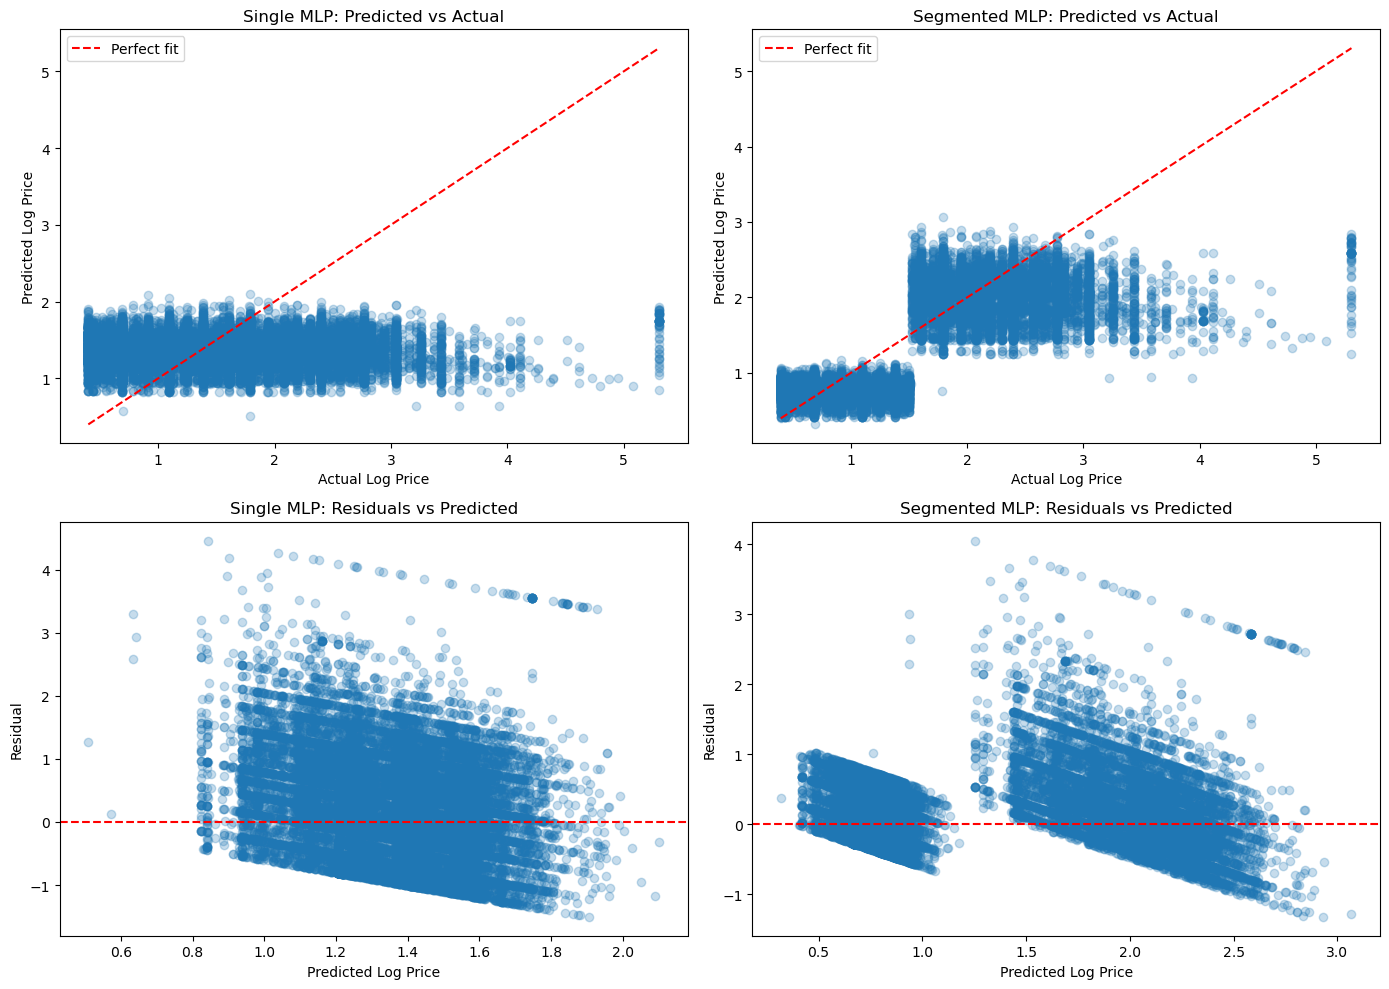

In [19]:
import matplotlib.pyplot as plt

# residuals
residuals_single = y_test.flatten() - y_pred_single
residuals_segmented = y_test.flatten() - y_pred_segmented

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# single predicted vs actual
axes[0, 0].scatter(y_test.flatten(), y_pred_single, alpha=0.25)
axes[0, 0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    label='Perfect fit'
)
axes[0, 0].set_title("Single MLP: Predicted vs Actual")
axes[0, 0].set_xlabel("Actual Log Price")
axes[0, 0].set_ylabel("Predicted Log Price")
axes[0, 0].legend()

# segmented predicted vs actual
axes[0, 1].scatter(y_test.flatten(), y_pred_segmented, alpha=0.25)
axes[0, 1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    label='Perfect fit'
)
axes[0, 1].set_title("Segmented MLP: Predicted vs Actual")
axes[0, 1].set_xlabel("Actual Log Price")
axes[0, 1].set_ylabel("Predicted Log Price")
axes[0, 1].legend()

# single residuals
axes[1, 0].scatter(y_pred_single, residuals_single, alpha=0.25)
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_title("Single MLP: Residuals vs Predicted")
axes[1, 0].set_xlabel("Predicted Log Price")
axes[1, 0].set_ylabel("Residual")

# segmented residuals
axes[1, 1].scatter(y_pred_segmented, residuals_segmented, alpha=0.25)
axes[1, 1].axhline(0, color='red', linestyle='--')
axes[1, 1].set_title("Segmented MLP: Residuals vs Predicted")
axes[1, 1].set_xlabel("Predicted Log Price")
axes[1, 1].set_ylabel("Residual")

plt.tight_layout()
plt.show()

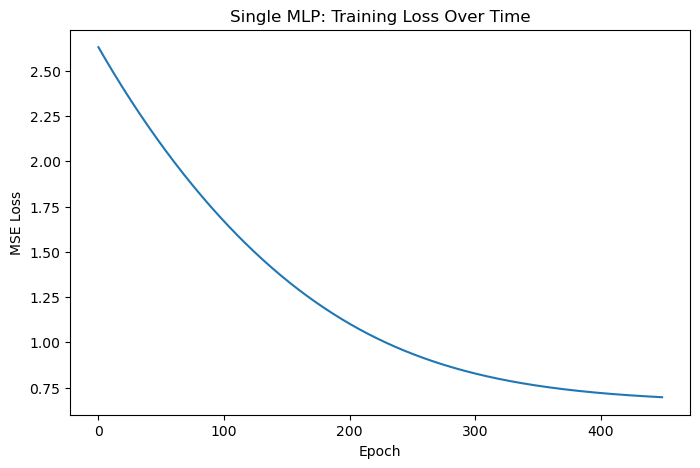

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(errors_single)
plt.title("Single MLP: Training Loss Over Time")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

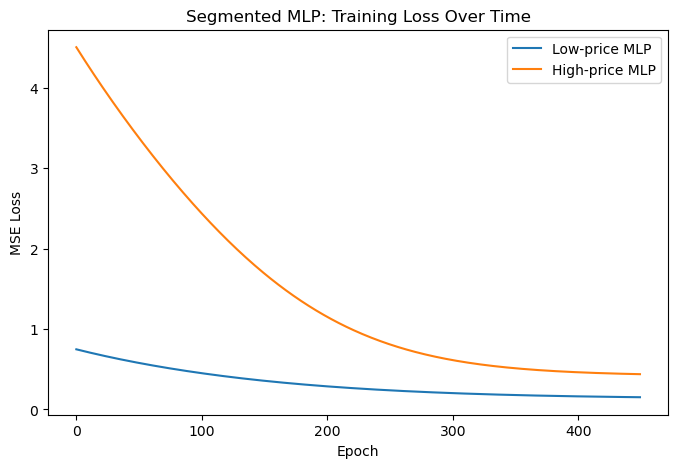

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(errors_low, label="Low-price MLP")
plt.plot(errors_high, label="High-price MLP")
plt.title("Segmented MLP: Training Loss Over Time")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()